# Trustworthiness of Models based on Language

**Authors:** Hannah Buch, Yassine Ajoud

*Do models perform equally well on various languages?*

We ask two models the same 50 literature questions, once in English and once in Polish. Every question has a known answer, so we can measure accuracy per language and see if the models get worse in Polish.

## Sections

1. Setup
2. The questions
3. Asking the models
4. Evaluation
5. Results
6. Findings

## 1. Setup

We use `transformers` with local models. No API keys are needed.

In [ ]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.utils import logging

# hide the repeated generation warnings
logging.set_verbosity_error()

# the two models we compare, one llama and one qwen
MODELS = ["TinyLlama/TinyLlama-1.1B-Chat-v1.0", "Qwen/Qwen2.5-1.5B-Instruct"]
MAX_NEW_TOKENS = 64

## 2. The questions

50 simple literature questions with one clear answer. Every question exists in English and in Polish (the Polish versions use the official Polish book titles). The correct answer is always an author name.

Every question has a list of accepted spellings and we count the answer as correct if it contains any of them.

In [ ]:
QUESTIONS = [
    {"en": 'Who wrote the book "Romeo and Juliet"?',
     "pl": 'Kto napisał książkę "Romeo i Julia"?',
     "answer": ["shakespeare", "szekspir"]},
    {"en": 'Who wrote the book "Harry Potter and the Philosopher\'s Stone"?',
     "pl": 'Kto napisał książkę "Harry Potter i Kamień Filozoficzny"?',
     "answer": ["rowling"]},
    {"en": 'Who wrote the book "The Lord of the Rings"?',
     "pl": 'Kto napisał książkę "Władca Pierścieni"?',
     "answer": ["tolkien"]},
    {"en": 'Who wrote the book "The Little Prince"?',
     "pl": 'Kto napisał książkę "Mały Książę"?',
     "answer": ["exupery", "exupéry"]},
    {"en": 'Who wrote the book "Pride and Prejudice"?',
     "pl": 'Kto napisał książkę "Duma i uprzedzenie"?',
     "answer": ["austen"]},
    {"en": 'Who wrote the book "1984"?',
     "pl": 'Kto napisał książkę "Rok 1984"?',
     "answer": ["orwell"]},
    {"en": 'Who wrote the book "Animal Farm"?',
     "pl": 'Kto napisał książkę "Folwark zwierzęcy"?',
     "answer": ["orwell"]},
    {"en": 'Who wrote the book "Crime and Punishment"?',
     "pl": 'Kto napisał książkę "Zbrodnia i kara"?',
     "answer": ["dostoevsky", "dostojewski"]},
    {"en": 'Who wrote the book "War and Peace"?',
     "pl": 'Kto napisał książkę "Wojna i pokój"?',
     "answer": ["tolstoy", "tołstoj", "tolstoj"]},
    {"en": 'Who wrote the book "The Adventures of Tom Sawyer"?',
     "pl": 'Kto napisał książkę "Przygody Tomka Sawyera"?',
     "answer": ["twain"]},
    {"en": 'Who wrote the book "A Christmas Carol"?',
     "pl": 'Kto napisał książkę "Opowieść wigilijna"?',
     "answer": ["dickens"]},
    {"en": 'Who wrote the book "The Old Man and the Sea"?',
     "pl": 'Kto napisał książkę "Stary człowiek i morze"?',
     "answer": ["hemingway"]},
    {"en": 'Who wrote the book "Don Quixote"?',
     "pl": 'Kto napisał książkę "Don Kichot"?',
     "answer": ["cervantes"]},
    {"en": 'Who wrote the book "Faust"?',
     "pl": 'Kto napisał książkę "Faust"?',
     "answer": ["goethe"]},
    {"en": 'Who wrote the book "The Odyssey"?',
     "pl": 'Kto napisał książkę "Odyseja"?',
     "answer": ["homer"]},
    {"en": 'Who wrote the book "Alice\'s Adventures in Wonderland"?',
     "pl": 'Kto napisał książkę "Alicja w Krainie Czarów"?',
     "answer": ["carroll"]},
    {"en": 'Which writer created the character Sherlock Holmes?',
     "pl": 'Który pisarz stworzył postać Sherlocka Holmesa?',
     "answer": ["doyle"]},
    {"en": 'Who wrote the book "Murder on the Orient Express"?',
     "pl": 'Kto napisał książkę "Morderstwo w Orient Expressie"?',
     "answer": ["christie"]},
    {"en": 'Who wrote the book "The Great Gatsby"?',
     "pl": 'Kto napisał książkę "Wielki Gatsby"?',
     "answer": ["fitzgerald"]},
    {"en": 'Who wrote the book "Moby Dick"?',
     "pl": 'Kto napisał książkę "Moby Dick"?',
     "answer": ["melville"]},
    {"en": 'Who wrote the book "Robinson Crusoe"?',
     "pl": 'Kto napisał książkę "Robinson Crusoe"?',
     "answer": ["defoe"]},
    {"en": 'Who wrote the book "Gulliver\'s Travels"?',
     "pl": 'Kto napisał książkę "Podróże Guliwera"?',
     "answer": ["swift"]},
    {"en": 'Who wrote the book "Frankenstein"?',
     "pl": 'Kto napisał książkę "Frankenstein"?',
     "answer": ["shelley"]},
    {"en": 'Who wrote the book "Dracula"?',
     "pl": 'Kto napisał książkę "Dracula"?',
     "answer": ["stoker"]},
    {"en": 'Who wrote the book "The Picture of Dorian Gray"?',
     "pl": 'Kto napisał książkę "Portret Doriana Graya"?',
     "answer": ["wilde"]},
    {"en": 'Who wrote the book "Twenty Thousand Leagues Under the Sea"?',
     "pl": 'Kto napisał książkę "20 000 mil podmorskiej żeglugi"?',
     "answer": ["verne"]},
    {"en": 'Who wrote the book "The Jungle Book"?',
     "pl": 'Kto napisał książkę "Księga dżungli"?',
     "answer": ["kipling"]},
    {"en": 'Who wrote the book "Anne of Green Gables"?',
     "pl": 'Kto napisał książkę "Ania z Zielonego Wzgórza"?',
     "answer": ["montgomery"]},
    {"en": 'Who wrote the book "Pippi Longstocking"?',
     "pl": 'Kto napisał książkę "Pippi Pończoszanka"?',
     "answer": ["lindgren"]},
    {"en": 'Who wrote the book "Charlie and the Chocolate Factory"?',
     "pl": 'Kto napisał książkę "Charlie i fabryka czekolady"?',
     "answer": ["dahl"]},
    {"en": 'Who wrote the book "Winnie-the-Pooh"?',
     "pl": 'Kto napisał książkę "Kubuś Puchatek"?',
     "answer": ["milne"]},
    {"en": 'Who wrote the book "The Chronicles of Narnia"?',
     "pl": 'Kto napisał książkę "Opowieści z Narnii"?',
     "answer": ["lewis"]},
    {"en": 'Who wrote the book "The Trial"?',
     "pl": 'Kto napisał książkę "Proces"?',
     "answer": ["kafka", "kafki"]},
    {"en": 'Who wrote the book "The Stranger"?',
     "pl": 'Kto napisał książkę "Obcy"?',
     "answer": ["camus"]},
    {"en": 'Who wrote the book "One Hundred Years of Solitude"?',
     "pl": 'Kto napisał książkę "Sto lat samotności"?',
     "answer": ["marquez", "márquez"]},
    {"en": 'Who wrote the book "The Alchemist"?',
     "pl": 'Kto napisał książkę "Alchemik"?',
     "answer": ["coelho"]},
    {"en": 'Who wrote the book "The Name of the Rose"?',
     "pl": 'Kto napisał książkę "Imię róży"?',
     "answer": ["umberto"]},
    {"en": 'Who wrote the book "The Three Musketeers"?',
     "pl": 'Kto napisał książkę "Trzej muszkieterowie"?',
     "answer": ["dumas"]},
    {"en": 'Who wrote the book "Les Miserables"?',
     "pl": 'Kto napisał książkę "Nędznicy"?',
     "answer": ["hugo"]},
    {"en": 'Who wrote the book "Quo Vadis"?',
     "pl": 'Kto napisał książkę "Quo vadis"?',
     "answer": ["sienkiewicz"]},
    {"en": 'Who wrote the book "Pan Tadeusz"?',
     "pl": 'Kto napisał książkę "Pan Tadeusz"?',
     "answer": ["mickiewicz"]},
    {"en": 'Who wrote "The Witcher" books?',
     "pl": 'Kto napisał cykl książek "Wiedźmin"?',
     "answer": ["sapkowski"]},
    {"en": 'Who wrote the book "Solaris"?',
     "pl": 'Kto napisał książkę "Solaris"?',
     "answer": ["stanisław lem", "stanislaw lem"]},
    {"en": 'Which writer created the character James Bond?',
     "pl": 'Który pisarz stworzył postać Jamesa Bonda?',
     "answer": ["fleming"]},
    {"en": 'Who wrote the book "The Divine Comedy"?',
     "pl": 'Kto napisał książkę "Boska komedia"?',
     "answer": ["dante"]},
    {"en": 'Who wrote the book "Brave New World"?',
     "pl": 'Kto napisał książkę "Nowy wspaniały świat"?',
     "answer": ["huxley"]},
    {"en": 'Who wrote the book "The Catcher in the Rye"?',
     "pl": 'Kto napisał książkę "Buszujący w zbożu"?',
     "answer": ["salinger"]},
    {"en": 'Who wrote the book "Lord of the Flies"?',
     "pl": 'Kto napisał książkę "Władca much"?',
     "answer": ["golding"]},
    {"en": 'Who wrote the book "Treasure Island"?',
     "pl": 'Kto napisał książkę "Wyspa skarbów"?',
     "answer": ["stevenson"]},
    {"en": 'Who wrote the book "The Shining"?',
     "pl": 'Kto napisał książkę "Lśnienie"?',
     "answer": ["stephen king", "stephena kinga"]},
]


questions: 50


## 3. Asking the models

We send each question to the model and save the answer, the time it took and the number of generated tokens.

In [3]:
def load_model(model_id):
    print("loading", model_id)
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, dtype="auto")
    model.eval()
    return model, tokenizer


def ask(model, tokenizer, question):
    messages = [{"role": "user", "content": question}]
    text = tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    start = time.time()
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    seconds = round(time.time() - start, 1)

    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return answer, seconds, len(new_tokens)

A quick try with one question in both languages:

In [4]:
model, tokenizer = load_model(MODELS[1])

answer, seconds, tokens = ask(model, tokenizer, QUESTIONS[0]["en"])
print(QUESTIONS[0]["en"])
print(answer)

answer, seconds, tokens = ask(model, tokenizer, QUESTIONS[0]["pl"])
print(QUESTIONS[0]["pl"])
print(answer)

del model, tokenizer

loading Qwen/Qwen2.5-1.5B-Instruct


Who wrote the book "Romeo and Juliet"?
William Shakespeare wrote the play "Romeo and Juliet."


Kto napisał książkę "Romeo i Julia"?
Autorami książki "Romeo i Julia" są William Shakespeare i Giuseppe Verdi.


## 4. Evaluation

An answer counts as correct if it contains one of the accepted spellings of the author name. The check ignores upper and lower case.

In [5]:
def check_answer(answer, accepted):
    answer = answer.lower()
    for name in accepted:
        if name in answer:
            return True
    return False


def evaluate(model, tokenizer, lang):
    rows = []
    for i, q in enumerate(QUESTIONS):
        answer, seconds, tokens = ask(model, tokenizer, q[lang])
        rows.append({
            "question": i + 1,
            "correct": check_answer(answer, q["answer"]),
            "seconds": seconds,
            "tokens": tokens,
            "answer": answer[:60],
        })
    return pd.DataFrame(rows)

## 5. Results

Each model answers all 50 questions in English and all 50 in Polish.

In [6]:
results = {}
for model_name in MODELS:
    model, tokenizer = load_model(model_name)
    results[model_name] = {
        "english": evaluate(model, tokenizer, "en"),
        "polish": evaluate(model, tokenizer, "pl"),
    }
    del model, tokenizer

loading TinyLlama/TinyLlama-1.1B-Chat-v1.0


loading Qwen/Qwen2.5-1.5B-Instruct


In [7]:
rows = []
for model_name in MODELS:
    for language in ["english", "polish"]:
        df = results[model_name][language]
        rows.append({
            "model": model_name.split("/")[-1],
            "language": language,
            "accuracy": df["correct"].mean(),
            "avg_seconds": df["seconds"].mean(),
            "avg_tokens": df["tokens"].mean(),
        })

summary = pd.DataFrame(rows).round(2)
summary

,model,language,accuracy,avg_seconds,avg_tokens
0,TinyLlama-1.1B-Chat-v1.0,english,0.96,2.68,26.16
1,TinyLlama-1.1B-Chat-v1.0,polish,0.44,4.46,46.34
2,Qwen2.5-1.5B-Instruct,english,0.96,3.81,22.72
3,Qwen2.5-1.5B-Instruct,polish,0.22,7.13,46.88


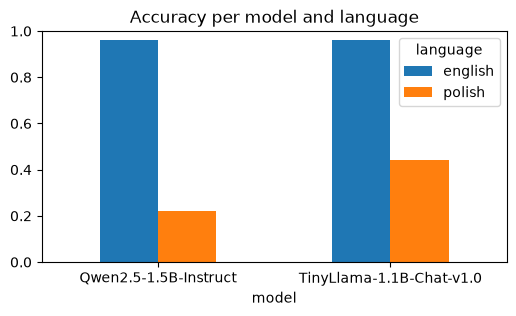

In [8]:
summary.pivot(index="model", columns="language", values="accuracy").plot(kind="bar", ylim=(0, 1), rot=0, figsize=(6, 3))
plt.title("Accuracy per model and language")
plt.show()

The per-question tables show what the models answered:

In [9]:
results[MODELS[0]]["polish"]

,question,correct,seconds,tokens,answer
0,1,True,2.5,23,"""Romeo i Julia"" jest powieścią napisaną przez ..."
1,2,True,5.4,55,"""Harry Potter i Kamień Filozoficzny"" (Harry Po..."
2,3,False,4.4,45,"""The Wizard of Oz"" by L. Frank Baum is the aut..."
3,4,False,4.3,44,"""Mały Książę"" jest autobiograficzną powieścią ..."
4,5,False,4.9,52,"""Duma i uprzedzenie"" (The Duty and the Delusio..."
5,6,True,2.8,26,"""Rok 1984"" jest powieścią napisaną przez Georg..."
6,7,False,6.0,64,"""Folwark zwierzęcy"" (The Shepherd's Life) by J..."
7,8,False,3.8,39,"""Zbrodnia i kara"" (The Crime and the Punishmen..."
8,9,False,3.7,38,"""Wojna i pokój"" (eng. ""War and Peace"") jest po..."
9,10,True,6.0,64,"""Przygody Tomka Sawyera"" (The Adventures of To..."


In [10]:
results[MODELS[1]]["polish"]

,question,correct,seconds,tokens,answer
0,1,True,3.5,20,"Autorami książki ""Romeo i Julia"" są William Sh..."
1,2,True,4.4,26,"Autorami książki ""Harry Potter i Kamień Filozo..."
2,3,False,9.3,64,"Przepraszam, ale nie mam informacji na temat a..."
3,4,False,9.1,64,"Autorami książki ""Mały Książę"" są:\n\n1. Jan K..."
4,5,False,3.6,20,"Autorą książki ""Duma i uprzedzenie"" jest Jan K..."
5,6,True,3.2,17,"Autorą książki ""Rok 1984"" jest George Orwell."
6,7,False,9.1,64,"Autorami książki ""Folwark zwierzęcy"" są:\n\n1...."
7,8,False,9.0,64,"Przepraszam, ale nie mam informacji na temat a..."
8,9,False,4.0,24,"Autorami książki ""Wojna i Pokój"" są Jan Karski..."
9,10,False,4.8,29,"Autorami książki ""Przygody Tomka Sawyera"" są J..."


## 6. Findings

- In English both models look the same: 48 of 50 correct (0.96). If we had only tested in English we would call both models equally trustworthy.
- In Polish both models break down, TinyLlama to 0.44 and Qwen to 0.22. So the answer to the project question is no, the models do not perform equally well across languages.
- The surprise: the small English-centered TinyLlama beats the newer multilingual Qwen in Polish. The two fail in very different ways though.
- Qwen either refuses ("Przepraszam, ale nie mam informacji...") or invents authors. It answers "Wojna i pokój" with Jan Karski and "Robinson Crusoe" with Jules Verne. The facts are in the model, it answers these questions correctly in English, but the Polish wording makes them unreachable.
- TinyLlama mostly ignores that the question is Polish and answers half in English. It often mistranslates the title ("Don Kichot" becomes "The Donkey") but the author name still comes out right often enough to score points. For "Władca Pierścieni" it talked about the Wizard of Oz instead.
- Polish answers also cost more: both models write roughly twice as many tokens per answer and need clearly more time than in English.

So both models carry the same knowledge but only reach it reliably in English. Accuracy measured in one language says little about another.